## Loading packages

In [1]:
import torch
from torch import nn
import kagglehub
import os
import numpy as np
from glob import glob
from matplotlib import pyplot as plt
from PIL import Image

In [2]:
BATCH_SIZE = 50
device = 'cpu'
device

'cpu'

## Loading dataset

In [5]:
BASE_PATH = os.path.join(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"),"chest_xray")

DATASET_PATH = {}

DATASET_PATH['train'] = os.path.join(BASE_PATH, 'train')
DATASET_PATH['test'] = os.path.join(BASE_PATH, 'test')
DATASET_PATH['val'] = os.path.join(BASE_PATH, 'val')

LABELS = {0:'NORMAL',
          1:'PNEUMONIA'}

IMAGE_SIZE = (128, 128)

def load_dataset(dataset_name):
  X = []
  Y = []
  for (label_encoding, label) in LABELS.items():
    tmp = glob(os.path.join(DATASET_PATH[dataset_name], label, "*.jpeg"))
    for img_path in tmp:
      img = Image.open(img_path).resize(IMAGE_SIZE).convert('L')
      img_array = np.array(img)

      img_array = np.expand_dims(img_array, axis=1)
      X.append(img_array)
      Y.append(label_encoding)

  X = np.array(X)
  Y = np.array(Y)
  return X, Y


X_train, y_train = load_dataset('train')
X_test, y_test = load_dataset('test')
X_val, y_val = load_dataset('val')

X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


((5216, 128, 128, 3),
 (5216,),
 (624, 128, 128, 3),
 (624,),
 (16, 128, 128, 3),
 (16,))

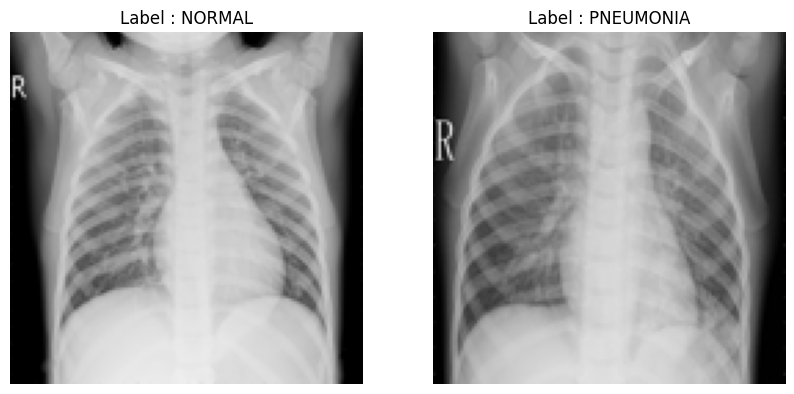

In [6]:
plt.figure(figsize=[10,7])
plt.subplot(1,2,1)
plt.imshow(X_val[0], cmap="gray")
plt.axis('off')
plt.title(f"Label : {LABELS[y_val[0]]}")

plt.subplot(1,2,2)
plt.imshow(X_val[-1], cmap="gray")
plt.axis('off')
plt.title(f"Label : {LABELS[y_val[-1]]}")

plt.show()

In [7]:
X_train = torch.tensor(X_train, device=device)
X_test = torch.tensor(X_test, device=device)
X_val = torch.tensor(X_val, device=device)
y_train = torch.tensor(y_train, device=device)
y_test = torch.tensor(y_test, device=device)
y_val = torch.tensor(y_val, device=device)

X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

(torch.Size([5216, 128, 128, 3]),
 torch.Size([5216]),
 torch.Size([624, 128, 128, 3]),
 torch.Size([624]),
 torch.Size([16, 128, 128, 3]),
 torch.Size([16]))

In [8]:
X_train.min(), X_train.max(), X_test.min(), X_test.max(), X_val.min(), X_val.max()

(tensor(0, dtype=torch.uint8),
 tensor(255, dtype=torch.uint8),
 tensor(0, dtype=torch.uint8),
 tensor(255, dtype=torch.uint8),
 tensor(0, dtype=torch.uint8),
 tensor(251, dtype=torch.uint8))

In [9]:
def scale_img(image_set):
  return (image_set - image_set.min())/(image_set.max() - image_set.min())

X_train = scale_img(X_train)
X_test = scale_img(X_test)
X_val = scale_img(X_val)

X_train.min(), X_train.max(), X_test.min(), X_test.max(), X_val.min(), X_val.max()

(tensor(0.), tensor(1.), tensor(0.), tensor(1.), tensor(0.), tensor(1.))

In [27]:
X_train = X_train.permute(0,3,1,2)
X_test = X_test.permute(0,3,1,2)
X_val = X_val.permute(0,3,1,2)

In [28]:
trainset = torch.utils.data.TensorDataset(X_train, y_train)

In [29]:
NUM_WORKERS = 0
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=NUM_WORKERS)

## Convolutional Neural Network

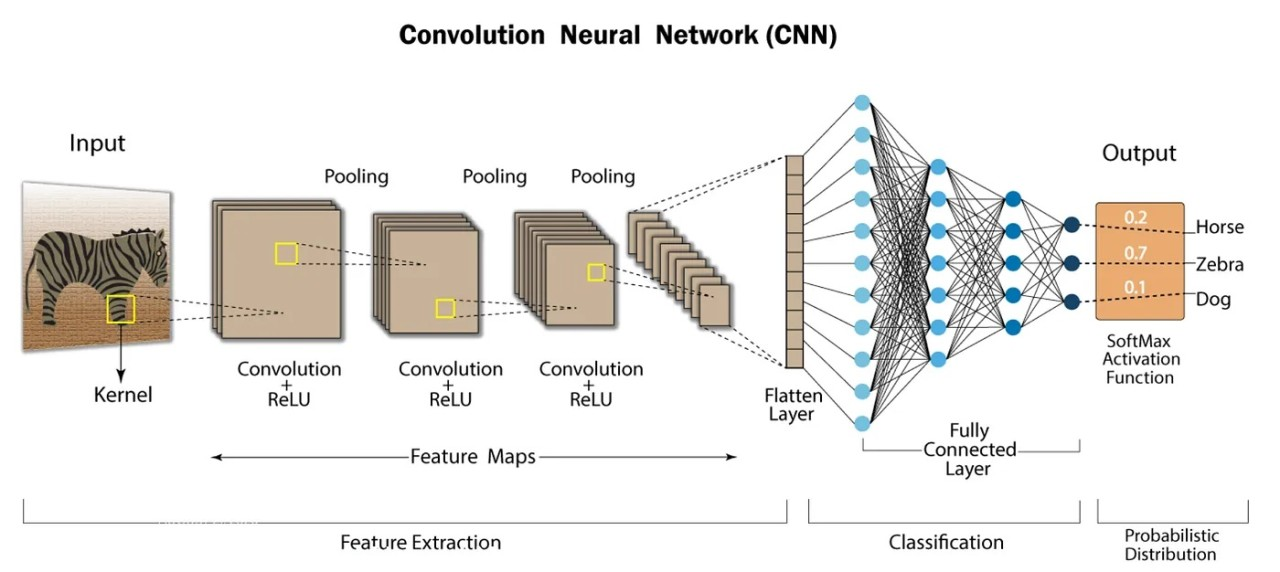

### Build a CNN

In [14]:
from typing import OrderedDict

class ConvNeuralNetwork(nn.Module):
  def __init__(self):
     super().__init__()

     self.network = nn.Sequential(
         OrderedDict([
             # Conv Layer 1
             ("conv1", nn.Conv2d(3,8,5)),
             ("relu1", nn.ReLU()),
             ("pool1", nn.MaxPool2d(3)),
             # Conv Layer 2
             ("conv2", nn.Conv2d(8,16,5)),
             ("relu2", nn.ReLU()),
             ("pool2", nn.MaxPool2d(3)),
             # Conv Layer 3
             ("conv3", nn.Conv2d(16,32,5)),
             ("relu3", nn.ReLU()),
             ("pool3", nn.MaxPool2d(3)),
             # Flatten Layer
             ("flatten", nn.Flatten()),
             # Fully connected Layer
             ("fc1", nn.Linear(32*5*5, 120)),
             ("relu4", nn.ReLU()),
             ("fc2", nn.Linear(120, 10)),
             ("relu5", nn.ReLU()),
             ("fc3", nn.Linear(10, 1)),
             ("sigmoid", nn.Sigmoid()),
         ])
     )
  def forward(self, X):
    return self.network(X)


model1 = ConvNeuralNetwork()
model1

ConvNeuralNetwork(
  (network): Sequential(
    (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1))
    (relu1): ReLU()
    (pool1): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (relu2): ReLU()
    (pool2): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (relu3): ReLU()
    (pool3): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): Linear(in_features=800, out_features=120, bias=True)
    (relu4): ReLU()
    (fc2): Linear(in_features=120, out_features=10, bias=True)
    (relu5): ReLU()
    (fc3): Linear(in_features=10, out_features=1, bias=True)
    (sigmoid): Sigmoid()
  )
)

### Optimizer and loss function

In [15]:
class EarlyStoppong:

  def __init__(self, patience=5, metric="valid_acc", threshold=0):
    self.patience = patience
    self.metric = metric
    self.threshold = threshold

    self.checking_table = []
    self.results = False
    self.curr = torch.inf
    self.prev = torch.inf

  def __call__(self, history):

    def check_accuracy(prev, curr, threshold):
      return (prev-curr) >= threshold

    def check_loss(prev, curr, threshold):
      return (prev-curr) <= threshold

    metrics_values = history[self.metric]

    self.curr = metrics_values[-1]
    if len(metrics_values)==1:
      self.prev = metrics_values[-1]
    else:
      self.prev = metrics_values[-2]

    if len(self.checking_table) == self.patience:
      if sum(self.checking_table) == self.patience:
        self.results=True
      self.checking_table = []

    else:
      if "acc" in self.metric:
        if check_accuracy(self.prev, self.curr, self.threshold):
          self.checking_table.append(0)
        else:
          self.checking_table.append(1)
      if "loss" in self.metric:
        if check_loss(self.prev, self.curr, self.threshold):
          self.checking_table.append(0)
        else:
          self.checking_table.append(1)

    return self.results

In [16]:
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)

def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None, epoch_nb=100):

    fig, ax = plt.subplots(figsize=(15, 4))

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, epoch_nb])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

In [17]:
lr = 0.01
alpha = 0.5
update_lr = lambda epoch : lr/(1+alpha*epoch)

early_stopping = EarlyStoppong()
loss_func = nn.BCELoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, update_lr)

In [18]:
def compute_accuracy(y_hat, y_true):
  N = y_hat.shape[0]
  class_matches = torch.argmax(y_true, axis=1) == torch.argmax(y_hat, axis=1)
  return torch.sum(class_matches)/N

In [19]:
def training_loop(model, trainset, loss_func, optimizer, scheduler=None, validset=None, monitoring = None, num_epochs=100):
  hist={
      'train_loss':[],
      'train_acc':[]
  }

  if validset != None:
    hist["val_acc"] = []
    hist["val_loss"] = []
    X_val, Y_val = validset

  for epoch in range(num_epochs):
    for X_train, Y_train in trainset:
      ## Set the model to train mode
      model.train()
      ## initialize the gradien to zero
      optimizer.zero_grad()
      ## Forward pass
      Y_train_hat = model(X_train)
      ## Compute loss
      loss = loss_func(Y_train_hat, Y_train)
      ## Backward
      loss.backward()
      optimizer.step()

    ## Store train metrics
    hist["train_loss"].append(loss.item())
    hist["train_acc"].append(compute_accuracy(Y_train_hat, Y_train).item())

    if scheduler != None:
      if epoch%5==0:
        scheduler.step()
    ## Print training progress
    digit = len(str(num_epochs))
    str_epoch = f"{str(epoch):{digit}s}"
    print(f"Epoch : [{str_epoch}/{num_epochs}]-------------------------------------")
    print(f"\t-> Trainset : \n *Loss={hist['train_loss']}\t *Acc={hist['train_acc']}")
    if validset != None:
      model.eval()
      with torch.inference_mode():
        Y_val_hat = model(X_val)
        loss = loss_func(Y_val_hat, Y_val)
        hist["val_loss"].append(loss.item())
        hist["val_acc"].append(compute_accuracy(Y_val_hat, Y_val).item())
        print(f"\t-> Validset : \n *Loss={hist['val_loss']}\t *Acc={hist['val_acc']}")

    if monitoring != None:
      if monitoring(hist):
        break
  return hist


In [20]:
hist = training_loop(model1, trainloader, loss_func, optimizer, scheduler, (X_val, y_val), early_stopping)

RuntimeError: Given groups=1, weight of size [8, 3, 5, 5], expected input[50, 128, 128, 3] to have 3 channels, but got 128 channels instead

In [22]:
model1(X_val)

RuntimeError: Given groups=1, weight of size [8, 3, 5, 5], expected input[16, 128, 128, 3] to have 3 channels, but got 128 channels instead

In [30]:
X_val.shape

torch.Size([16, 3, 128, 128])